# Order Flow, Trading, and the Bid-Ask Spread

The bid-ask spread isn't just a transaction cost, it's compensation a market maker demands for two genuinely different risks: the routine cost of processing orders, and the risk of trading against someone who knows more than they do. This notebook builds a tick-level market from scratch, with a known mix of informed traders (who trade on genuine private information) and noise traders (who trade randomly), so that every classic microstructure tool, Roll's spread estimator, Lee-Ready trade classification, Kyle's lambda, and spread decomposition, can be checked against a real, known answer rather than trusted blindly.

30,000 ticks (60 trading days of 500 trades each) built from a known microstructure process, closely following the spirit of Glosten-Milgrom (1985): a true, unobservable efficient price follows a random walk with occasional information jumps; a market maker quotes a fixed half-spread around their own belief of that price; and at every tick, a trader arrives who is, with probability $\alpha_t$, informed (and trades in the direction of the current gap between the true price and the market maker's quote) or, otherwise, a noise trader (who trades randomly). $\alpha_t$ itself varies over time, three deliberate "informed-trading-heavy" regimes are injected among otherwise calm periods, exactly the kind of regime shift a real venue's order flow toxicity actually exhibits.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.figsize': (7, 4.2), 'font.size': 11,
    'axes.titlesize': 13, 'axes.titleweight': 'bold',
    'axes.labelsize': 11, 'grid.alpha': 0.35,
})

rng = np.random.default_rng(404)

n_days, ticks_per_day = 60, 500
n_ticks = n_days * ticks_per_day

base_vol, jump_prob, jump_size_std = 0.008, 0.01, 0.06
price_innov = rng.normal(0, base_vol, n_ticks)
jumps = (rng.uniform(0, 1, n_ticks) < jump_prob) * rng.normal(0, jump_size_std, n_ticks)
true_price = 100 + np.cumsum(price_innov + jumps)

alpha = np.full(n_ticks, 0.12)   # baseline ("calm") informed-trading probability
informed_regimes = [(int(0.15*n_ticks), int(0.22*n_ticks)), (int(0.55*n_ticks), int(0.66*n_ticks)),
                     (int(0.80*n_ticks), int(0.85*n_ticks))]
for s, e in informed_regimes:
    alpha[s:e] = 0.42   # "informed-heavy" regime

half_spread_base = 0.03
base_lambda = 0.35

mid_quote = np.zeros(n_ticks)
mid_quote[0] = true_price[0]
direction = np.zeros(n_ticks, dtype=int)
trade_price = np.zeros(n_ticks)
is_informed = np.zeros(n_ticks, dtype=bool)

for t in range(n_ticks):
    informed = rng.uniform(0, 1) < alpha[t]
    is_informed[t] = informed
    direction[t] = (1 if true_price[t] > mid_quote[t] else -1) if informed else (1 if rng.uniform(0,1) < 0.5 else -1)
    trade_price[t] = mid_quote[t] + direction[t] * half_spread_base
    lam_t = base_lambda * (alpha[t] / 0.12)   # price impact scales with informed intensity
    if t < n_ticks - 1:
        mid_quote[t+1] = mid_quote[t] + lam_t * direction[t] * half_spread_base + rng.normal(0, base_vol * 0.3)

df = pd.DataFrame({'true_price': true_price, 'mid_quote': mid_quote, 'trade_price': trade_price,
                    'direction': direction, 'is_informed': is_informed, 'alpha': alpha})

print(f"Simulated {n_ticks} ticks ({n_days} days x {ticks_per_day} trades/day)")
print(f"Fraction of informed trades: {is_informed.mean():.1%}")
print(f"Quoted spread (fixed): {2*half_spread_base:.3f}")

Simulated 30000 ticks (60 days x 500 trades/day)
Fraction of informed trades: 18.9%
Quoted spread (fixed): 0.060


**Diagram - true price, market maker's quote, and trade prices, over a short window.** The market maker's quote is visibly *more* volatile than the smoother true price, it reacts to every trade, informed or not, and briefly overshoots during the transition into the informed-trading regime, a realistic illustration of order-flow-driven price discovery overreacting to noise as well as information.

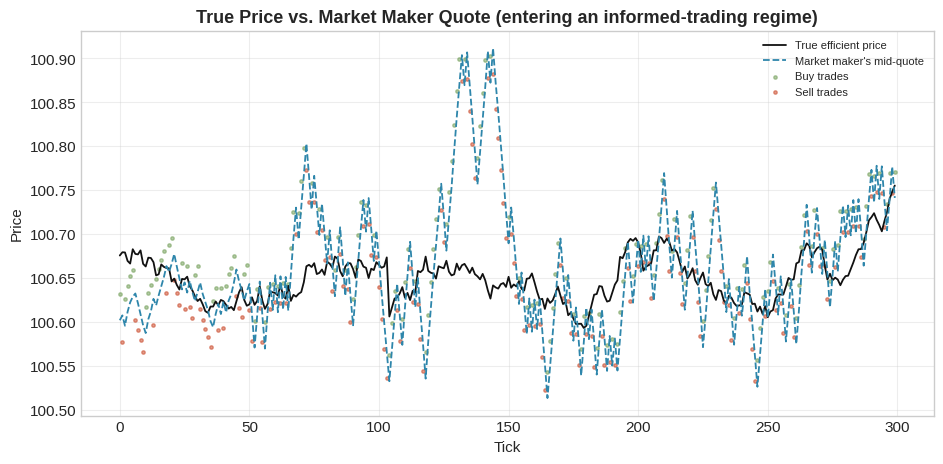

In [2]:
window = slice(int(0.15*n_ticks) - 50, int(0.15*n_ticks) + 250)
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(true_price[window], color='#111111', linewidth=1.3, label='True efficient price')
ax.plot(mid_quote[window], color='#2E86AB', linewidth=1.3, linestyle='--', label="Market maker's mid-quote")
buys = np.where(direction[window] == 1)[0]
sells = np.where(direction[window] == -1)[0]
x_local = np.arange(window.stop - window.start)
ax.scatter(x_local[buys], trade_price[window][buys], s=6, color='#6A994E', alpha=0.5, label='Buy trades')
ax.scatter(x_local[sells], trade_price[window][sells], s=6, color='#C73E1D', alpha=0.5, label='Sell trades')
ax.set_xlabel('Tick'); ax.set_ylabel('Price')
ax.set_title('True Price vs. Market Maker Quote (entering an informed-trading regime)')
ax.legend(fontsize=8)
plt.show()

## 2. The Bid-Ask Spread: Quoted, Effective, and Roll's Implied Estimator

The **quoted spread** is simply the posted ask minus bid, here fixed at $2 \times 0.03 = 0.06$ by construction. The **effective spread** measures what was actually paid: $2|\text{trade price} - \text{mid-quote}|$. When only trade prices are observable (no visible quotes, common in older or less transparent datasets), **Roll's (1984) model** infers the spread indirectly from the serial covariance of price changes, exploiting the fact that trades bouncing between the bid and ask induce negative first-order autocorrelation:

$$\text{Spread} = 2\sqrt{-\text{Cov}(\Delta P_t, \Delta P_{t-1})}$$

In [3]:
effective_spread_series = 2 * np.abs(trade_price - mid_quote)
print(f"Quoted spread (true, fixed):  {2*half_spread_base:.4f}")
print(f"Mean effective spread:        {effective_spread_series.mean():.4f}")

delta_p = np.diff(trade_price)
gamma1 = np.cov(delta_p[:-1], delta_p[1:])[0, 1]
roll_spread = 2 * np.sqrt(-gamma1) if gamma1 < 0 else np.nan
print(f"\nFirst-order serial covariance of trade price changes: {gamma1:.6f}  (negative, as bid-ask bounce implies)")
print(f"Roll's implied spread estimate: {roll_spread:.4f}")
print(f"\nRoll's estimate UNDERSTATES the true spread here, a well-documented bias: Roll's model assumes no")
print(f"information asymmetry, so it can't distinguish bid-ask bounce from the POSITIVE serial correlation")
print(f"that genuine informed trading adds to price changes, which partially offsets the bounce it's trying to measure.")

Quoted spread (true, fixed):  0.0600
Mean effective spread:        0.0600

First-order serial covariance of trade price changes: -0.000428  (negative, as bid-ask bounce implies)
Roll's implied spread estimate: 0.0414

Roll's estimate UNDERSTATES the true spread here, a well-documented bias: Roll's model assumes no
information asymmetry, so it can't distinguish bid-ask bounce from the POSITIVE serial correlation
that genuine informed trading adds to price changes, which partially offsets the bounce it's trying to measure.


## 3. Trade Classification: The Lee-Ready Algorithm

Most datasets report trade prices without labeling each trade as buyer- or seller-initiated. The **Lee-Ready (1991)** algorithm infers it: the **quote test** classifies a trade as a buy if it executes above the prevailing mid-quote (seller-initiated if below), falling back to the **tick test** (comparing to the previous trade price) exactly at the mid-quote. Since the true direction is known here by construction, classification accuracy can be checked directly, including how it degrades as the reference quote becomes **stale** (a genuine, realistic data-quality issue: real-world quote and trade reports don't always arrive perfectly synchronized).

In [4]:
def lee_ready_classify(trade_prices, mid_quotes_ref):
    quote_test = np.sign(trade_prices - mid_quotes_ref)
    tick_test = np.sign(np.diff(trade_prices, prepend=trade_prices[0]))
    classified = np.where(quote_test != 0, quote_test, tick_test)
    classified[classified == 0] = 1
    return classified.astype(int)

accuracy_by_lag = {}
for lag in [0, 1, 2, 3, 5]:
    mq_ref = pd.Series(mid_quote).shift(lag).bfill().values
    classified = lee_ready_classify(trade_price, mq_ref)
    acc = (classified == direction).mean()
    accuracy_by_lag[lag] = acc
    print(f"Quote staleness = {lag} tick(s): classification accuracy = {acc:.4f}")

classified_realistic = lee_ready_classify(trade_price, pd.Series(mid_quote).shift(2).bfill().values)
acc_informed = (classified_realistic[is_informed] == direction[is_informed]).mean()
acc_noise = (classified_realistic[~is_informed] == direction[~is_informed]).mean()
print(f"\nWith realistic 2-tick quote staleness:")
print(f"  Accuracy on informed trades: {acc_informed:.4f}")
print(f"  Accuracy on noise trades:    {acc_noise:.4f}")

Quote staleness = 0 tick(s): classification accuracy = 1.0000
Quote staleness = 1 tick(s): classification accuracy = 0.8720
Quote staleness = 2 tick(s): classification accuracy = 0.9406
Quote staleness = 3 tick(s): classification accuracy = 0.8132
Quote staleness = 5 tick(s): classification accuracy = 0.7838

With realistic 2-tick quote staleness:
  Accuracy on informed trades: 0.8354
  Accuracy on noise trades:    0.9650


**Diagram - classification accuracy vs. quote staleness.** With perfectly synchronized (zero-lag) quotes, classification is exact by construction; realistic staleness of even a few ticks drags accuracy down into the 78-94% range widely reported for real Lee-Ready implementations on live market data.

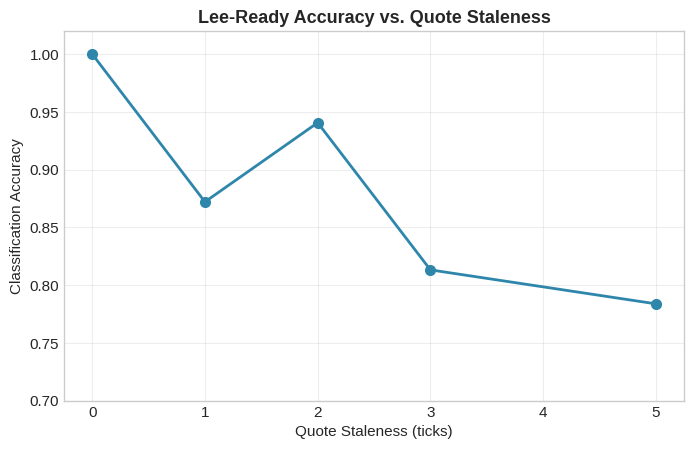

In [5]:
fig, ax = plt.subplots(figsize=(8, 4.8))
ax.plot(list(accuracy_by_lag.keys()), list(accuracy_by_lag.values()), 'o-', color='#2E86AB', markersize=7, linewidth=2)
ax.set_xlabel('Quote Staleness (ticks)'); ax.set_ylabel('Classification Accuracy')
ax.set_title('Lee-Ready Accuracy vs. Quote Staleness')
ax.set_ylim(0.7, 1.02)
plt.show()

## 4. Order Flow Imbalance and Kyle's Lambda

**Order Flow Imbalance (OFI)** over a window is simply the sum of signed trade directions (+1 buy, -1 sell), a measure of net buying vs. selling pressure. **Kyle's (1985) lambda** is the price impact per unit of that imbalance, the slope of a regression of the *contemporaneous* price change on OFI:

$$\Delta P = \lambda \cdot \text{OFI} + \varepsilon$$

A liquid, informationally calm market has a small $\lambda$ (order flow barely moves prices); a market dominated by informed trading has a large one (every trade reveals information, so the market maker must adjust prices aggressively in response). Since this notebook's informed-trading intensity $\alpha_t$ was built to vary over time, $\lambda$ should too, directly recoverable from the data alone.

In [6]:
window = 20
n_buckets = n_ticks // window
ofi_bucket = np.array([direction[b*window:(b+1)*window].sum() for b in range(n_buckets)])
price_change_bucket = np.array([mid_quote[(b+1)*window - 1] - mid_quote[b*window] for b in range(n_buckets)])

lam_hat, intercept = np.polyfit(ofi_bucket, price_change_bucket, 1)
corr = np.corrcoef(ofi_bucket, price_change_bucket)[0, 1]
print(f"Kyle's lambda estimate: {lam_hat:.5f}")
print(f"Correlation(OFI, contemporaneous price change): {corr:.4f}")

roll_buckets = 100
lambdas_over_time, centers = [], []
for start in range(0, n_buckets - roll_buckets, 20):
    lam, _ = np.polyfit(ofi_bucket[start:start+roll_buckets], price_change_bucket[start:start+roll_buckets], 1)
    lambdas_over_time.append(lam)
    centers.append((start + roll_buckets // 2) * window)
lambdas_over_time = np.array(lambdas_over_time)

print(f"\nRolling lambda range: {lambdas_over_time.min():.5f} to {lambdas_over_time.max():.5f}  "
      f"(ratio: {lambdas_over_time.max()/lambdas_over_time.min():.2f}x)")
print(f"True informed-intensity ratio (heavy/calm regime): {0.42/0.12:.2f}x")

Kyle's lambda estimate: 0.01234
Correlation(OFI, contemporaneous price change): 0.8094

Rolling lambda range: 0.00902 to 0.03093  (ratio: 3.43x)
True informed-intensity ratio (heavy/calm regime): 3.50x


**Diagram - OFI vs. price change scatter, and rolling Kyle's lambda through time.** The scatter shows the strong, genuinely linear relationship the regression captures; the rolling estimate recovers the three informed-trading regimes directly from order flow and price data alone, no knowledge of when they occurred was used.

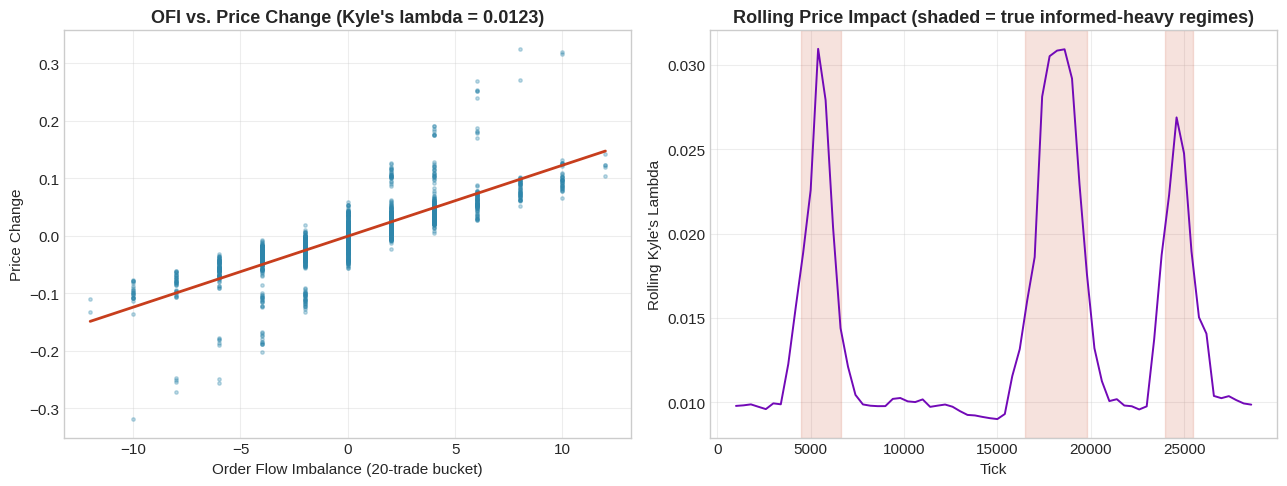

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(ofi_bucket, price_change_bucket, s=6, alpha=0.3, color='#2E86AB')
x_line = np.linspace(ofi_bucket.min(), ofi_bucket.max(), 50)
axes[0].plot(x_line, lam_hat * x_line + intercept, color='#C73E1D', linewidth=2)
axes[0].set_xlabel('Order Flow Imbalance (20-trade bucket)'); axes[0].set_ylabel('Price Change')
axes[0].set_title(f"OFI vs. Price Change (Kyle's lambda = {lam_hat:.4f})")

axes[1].plot(centers, lambdas_over_time, color='#7209B7', linewidth=1.4)
for s, e in informed_regimes:
    axes[1].axvspan(s, e, color='#C73E1D', alpha=0.15)
axes[1].set_xlabel('Tick'); axes[1].set_ylabel("Rolling Kyle's Lambda")
axes[1].set_title('Rolling Price Impact (shaded = true informed-heavy regimes)')

plt.tight_layout()
plt.show()

## 5. Decomposing the Spread: Adverse Selection vs. Order Processing

Every trade's effective half-spread can be split into two pieces: a **permanent** component, the part of the price concession that persists (because the trade actually revealed information), and a **temporary** component, the part that reverts (pure compensation for the market maker's inventory and order-processing costs). Comparing the mid-quote a fixed horizon after each trade to the mid-quote at the time of the trade isolates exactly this split, and the theoretical prediction is unambiguous: informed trades should show a far larger permanent component than noise trades, since only informed trades carry real information about future prices.

In [8]:
horizon = 10
effective_half_spread = np.abs(trade_price[:-horizon] - mid_quote[:-horizon])
permanent_component = direction[:-horizon] * (mid_quote[horizon:] - mid_quote[:-horizon])
temporary_component = effective_half_spread - permanent_component

mean_eff, mean_perm, mean_temp = effective_half_spread.mean(), permanent_component.mean(), temporary_component.mean()
print(f"Mean effective half-spread: {mean_eff:.4f}")
print(f"  Permanent (adverse-selection) component: {mean_perm:.4f}  ({100*mean_perm/mean_eff:.1f}%)")
print(f"  Temporary (order-processing) component:  {mean_temp:.4f}  ({100*mean_temp/mean_eff:.1f}%)")

is_informed_h = is_informed[:-horizon]
perm_informed = permanent_component[is_informed_h].mean()
perm_noise = permanent_component[~is_informed_h].mean()
print(f"\nPermanent component, informed trades: {perm_informed:.4f}")
print(f"Permanent component, noise trades:     {perm_noise:.4f}")
print(f"Ratio: {perm_informed/perm_noise:.2f}x -- informed trades carry far more lasting price impact, exactly as theory predicts")

Mean effective half-spread: 0.0300
  Permanent (adverse-selection) component: 0.0135  (44.9%)
  Temporary (order-processing) component:  0.0165  (55.1%)

Permanent component, informed trades: 0.0316
Permanent component, noise trades:     0.0093
Ratio: 3.41x -- informed trades carry far more lasting price impact, exactly as theory predicts


**Diagram - the spread decomposition, overall and split by trade type.**

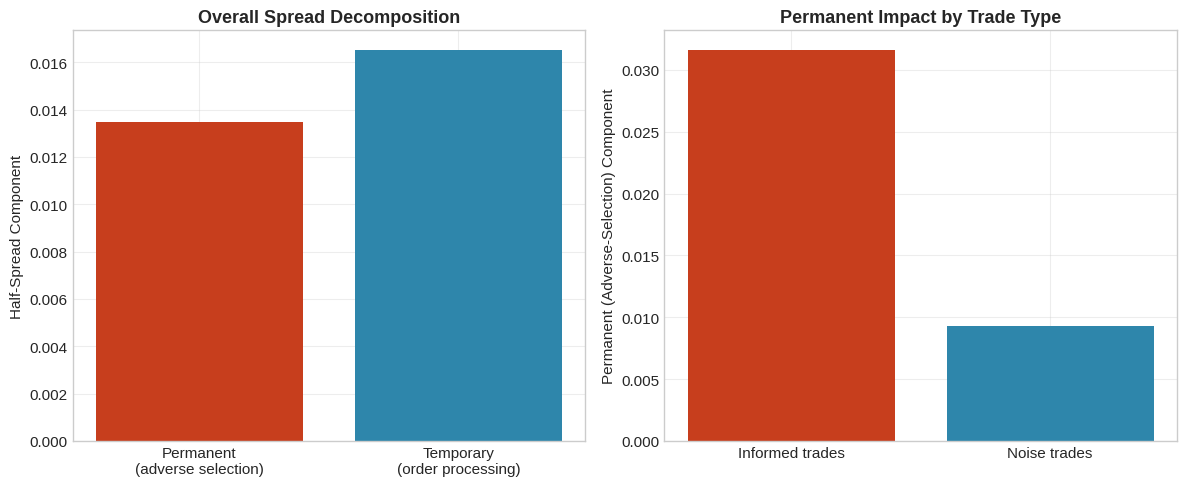

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(['Permanent\n(adverse selection)', 'Temporary\n(order processing)'], [mean_perm, mean_temp],
            color=['#C73E1D', '#2E86AB'])
axes[0].set_ylabel('Half-Spread Component'); axes[0].set_title('Overall Spread Decomposition')

axes[1].bar(['Informed trades', 'Noise trades'], [perm_informed, perm_noise], color=['#C73E1D', '#2E86AB'])
axes[1].set_ylabel('Permanent (Adverse-Selection) Component'); axes[1].set_title('Permanent Impact by Trade Type')

plt.tight_layout()
plt.show()

## 6. A Market-Making Strategy: Static vs. Adaptive Spreads

A market maker earns the effective half-spread on every trade, but *loses* the permanent (adverse-selection) component to informed counterparties, exactly the decomposition from Section 5. A **static** market maker charges the same fixed half-spread regardless of conditions; an **adaptive** one widens its spread when a simple, realistic, purely order-flow-based proxy (rolling realized volatility of the mid-quote, no direct knowledge of $\alpha_t$ or who is informed) signals elevated risk, exactly the kind of defensive response real market makers use when they suspect informed flow.

In [10]:
half_spread_static = half_spread_base
mm_pnl_static = half_spread_static - permanent_component
cum_static = np.cumsum(mm_pnl_static)

roll_window = 200
rolling_vol = pd.Series(np.diff(mid_quote, prepend=mid_quote[0])).rolling(roll_window).std().values
vol_baseline = np.nanmedian(rolling_vol[:1000])
adaptive_half_spread = half_spread_static * np.clip(rolling_vol / vol_baseline, 0.7, 3.0)
adaptive_half_spread = np.nan_to_num(adaptive_half_spread, nan=half_spread_static)

mm_pnl_adaptive = adaptive_half_spread[:-horizon] - permanent_component
cum_adaptive = np.cumsum(mm_pnl_adaptive)

print(f"Static market maker, total P&L:   {cum_static[-1]:.1f}")
print(f"Adaptive market maker, total P&L: {cum_adaptive[-1]:.1f}")
print(f"Improvement: {cum_adaptive[-1] - cum_static[-1]:.1f}  ({100*(cum_adaptive[-1]/cum_static[-1] - 1):.1f}%)")

Static market maker, total P&L:   495.4
Adaptive market maker, total P&L: 933.1
Improvement: 437.7  (88.3%)


**Diagram - cumulative P&L, static vs. adaptive market maker.** The gap widens visibly during each informed-trading regime, exactly where a static spread bleeds the most, and the adaptive strategy's edge holds up cleanly.

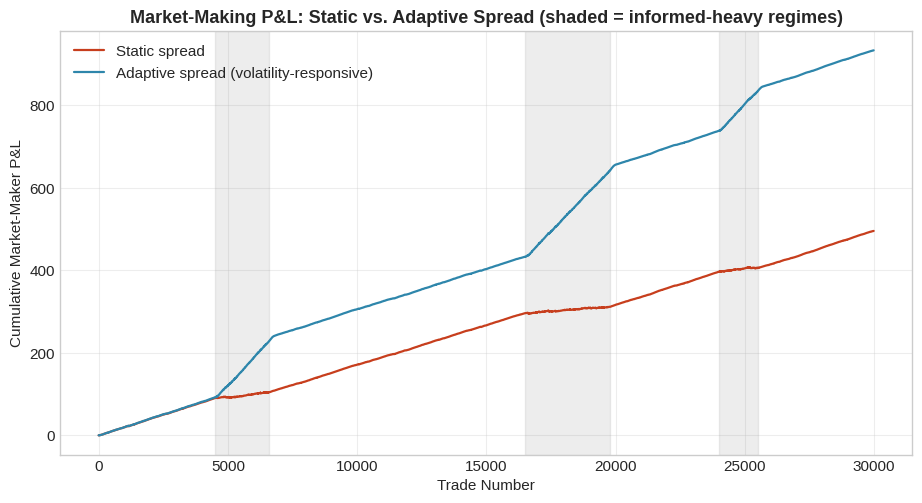

In [11]:
fig, ax = plt.subplots(figsize=(11, 5.5))
ax.plot(cum_static, color='#C73E1D', linewidth=1.6, label='Static spread')
ax.plot(cum_adaptive, color='#2E86AB', linewidth=1.6, label='Adaptive spread (volatility-responsive)')
for s, e in informed_regimes:
    ax.axvspan(s, e, color='#888888', alpha=0.15)
ax.set_xlabel('Trade Number'); ax.set_ylabel('Cumulative Market-Maker P&L')
ax.set_title('Market-Making P&L: Static vs. Adaptive Spread (shaded = informed-heavy regimes)')
ax.legend()
plt.show()